# Task 01 : Unsupervised

Dataset Access Link : https://archive.ics.uci.edu/dataset/342/mice+protein+expression

## 1. Dataset Description

The Mice Protein Expression dataset contains measurements of protein levels in mouse brains, along with experimental conditions such as genotype, treatment, and behaviour. It is used to study learning and memory, particularly differences between normal and trisomic (Down syndrome model) mice.

## 2. Data Loading & Cleaning

In [25]:
import pandas as pd

import numpy as np

In [27]:
df_mpe = pd.read_csv(r"C:\Users\sbast\Downloads\Data_Cortex_Nuclear(1).csv")

In [29]:
df_mpe.head()

,MouseID,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,...,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N,Genotype,Treatment,Behavior,class
0,309_1,0.503644,0.747193,0.430175,2.816329,5.990152,0.218830,0.177565,2.373744,0.232224,...,0.108336,0.427099,0.114783,0.131790,0.128186,1.675652,Control,Memantine,C/S,c-CS-m
1,309_2,0.514617,0.689064,0.411770,2.789514,5.685038,0.211636,0.172817,2.292150,0.226972,...,0.104315,0.441581,0.111974,0.135103,0.131119,1.743610,Control,Memantine,C/S,c-CS-m
2,309_3,0.509183,0.730247,0.418309,2.687201,5.622059,0.209011,0.175722,2.283337,0.230247,...,0.106219,0.435777,0.111883,0.133362,0.127431,1.926427,Control,Memantine,C/S,c-CS-m
3,309_4,0.442107,0.617076,0.358626,2.466947,4.979503,0.222886,0.176463,2.152301,0.207004,...,0.111262,0.391691,0.130405,0.147444,0.146901,1.700563,Control,Memantine,C/S,c-CS-m
4,309_5,0.434940,0.617430,0.358802,2.365785,4.718679,0.213106,0.173627,2.134014,0.192158,...,0.110694,0.434154,0.118481,0.140314,0.148380,1.839730,Control,Memantine,C/S,c-CS-m


In [31]:
df_mpe.shape

(1080, 82)

In [33]:
df_mpe.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1080 entries, 0 to 1079
Data columns (total 82 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   MouseID          1080 non-null   object 
 1   DYRK1A_N         1077 non-null   float64
 2   ITSN1_N          1077 non-null   float64
 3   BDNF_N           1077 non-null   float64
 4   NR1_N            1077 non-null   float64
 5   NR2A_N           1077 non-null   float64
 6   pAKT_N           1077 non-null   float64
 7   pBRAF_N          1077 non-null   float64
 8   pCAMKII_N        1077 non-null   float64
 9   pCREB_N          1077 non-null   float64
 10  pELK_N           1077 non-null   float64
 11  pERK_N           1077 non-null   float64
 12  pJNK_N           1077 non-null   float64
 13  PKCA_N           1077 non-null   float64
 14  pMEK_N           1077 non-null   float64
 15  pNR1_N           1077 non-null   float64
 16  pNR2A_N          1077 non-null   float64
 17  pNR2B_N       

In [35]:
df_mpe.describe()

,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,...,SHH_N,BAD_N,BCL2_N,pS6_N,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N
count,1077.000000,1077.000000,1077.000000,1077.000000,1077.000000,1077.000000,1077.000000,1077.000000,1077.000000,1077.000000,...,1080.000000,867.000000,795.000000,1080.000000,1005.000000,1080.000000,900.000000,870.000000,810.000000,1080.000000
mean,0.425810,0.617102,0.319088,2.297269,3.843934,0.233168,0.181846,3.537109,0.212574,1.428682,...,0.226676,0.157914,0.134762,0.121521,0.131053,0.446073,0.169609,0.183135,0.205440,1.337784
std,0.249362,0.251640,0.049383,0.347293,0.933100,0.041634,0.027042,1.295169,0.032587,0.466904,...,0.028989,0.029537,0.027417,0.014276,0.023863,0.066432,0.059402,0.040406,0.055514,0.317126
min,0.145327,0.245359,0.115181,1.330831,1.737540,0.063236,0.064043,1.343998,0.112812,0.429032,...,0.155869,0.088305,0.080657,0.067254,0.085419,0.258626,0.079691,0.105537,0.101787,0.586479
25%,0.288121,0.473361,0.287444,2.057411,3.155678,0.205755,0.164595,2.479834,0.190823,1.203665,...,0.206395,0.136424,0.115554,0.110839,0.113506,0.398082,0.125848,0.155121,0.165143,1.081423
50%,0.366378,0.565782,0.316564,2.296546,3.760855,0.231177,0.182302,3.326520,0.210594,1.355846,...,0.224000,0.152313,0.129468,0.121626,0.126523,0.448459,0.158240,0.174935,0.193994,1.317441
75%,0.487711,0.698032,0.348197,2.528481,4.440011,0.257261,0.197418,4.481940,0.234595,1.561316,...,0.241655,0.174017,0.148235,0.131955,0.143652,0.490773,0.197876,0.204542,0.235215,1.585824
max,2.516367,2.602662,0.497160,3.757641,8.482553,0.539050,0.317066,7.464070,0.306247,6.113347,...,0.358289,0.282016,0.261506,0.158748,0.256529,0.759588,0.479763,0.360692,0.413903,2.129791


In [37]:
df_mpe.isnull().sum().sort_values(ascending = False)

BCL2_N       285
H3MeK4_N     270
BAD_N        213
EGR1_N       210
H3AcK18_N    180
            ... 
nNOS_N         0
Tau_N          0
GFAP_N         0
GluR3_N        0
class          0
Length: 82, dtype: int64

In [39]:
# Removing non-numeric values for clustering 

df_mpe_numeric = df_mpe.select_dtypes(include = ["float64", "int64"])

In [41]:
# Imputing missing values using mean imputation 

df_mpe_numeric = df_mpe_numeric.fillna(df_mpe_numeric.mean())

In [43]:
# Checking duplicate observation 

df_mpe_numeric.duplicated().sum()

0

## 3. Exploratory Data Analysis (EDA)

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns

### 3.1 Histogram

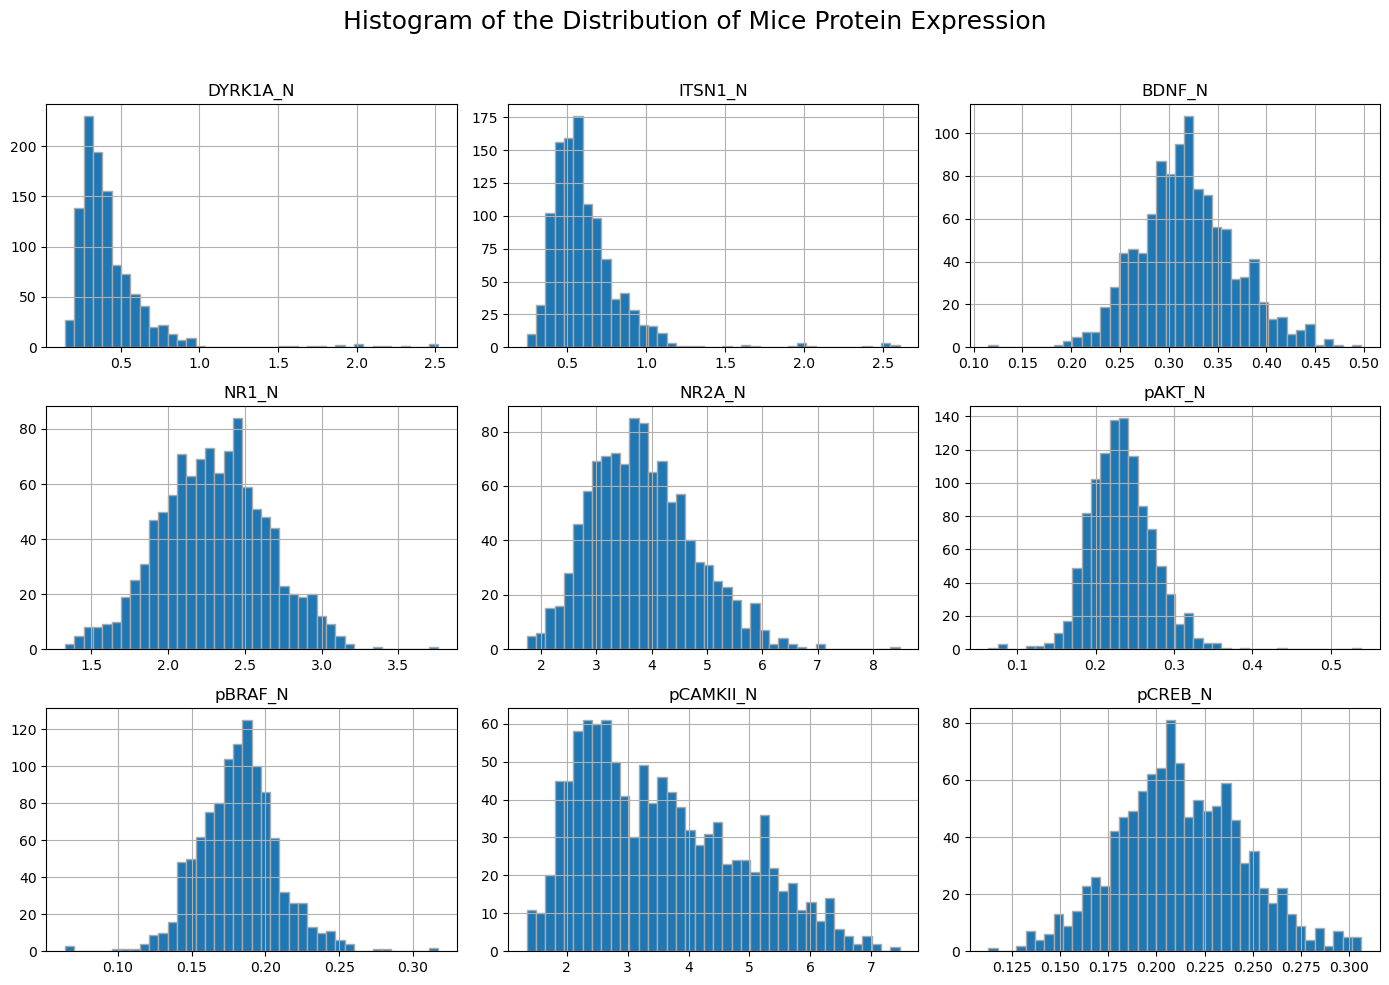

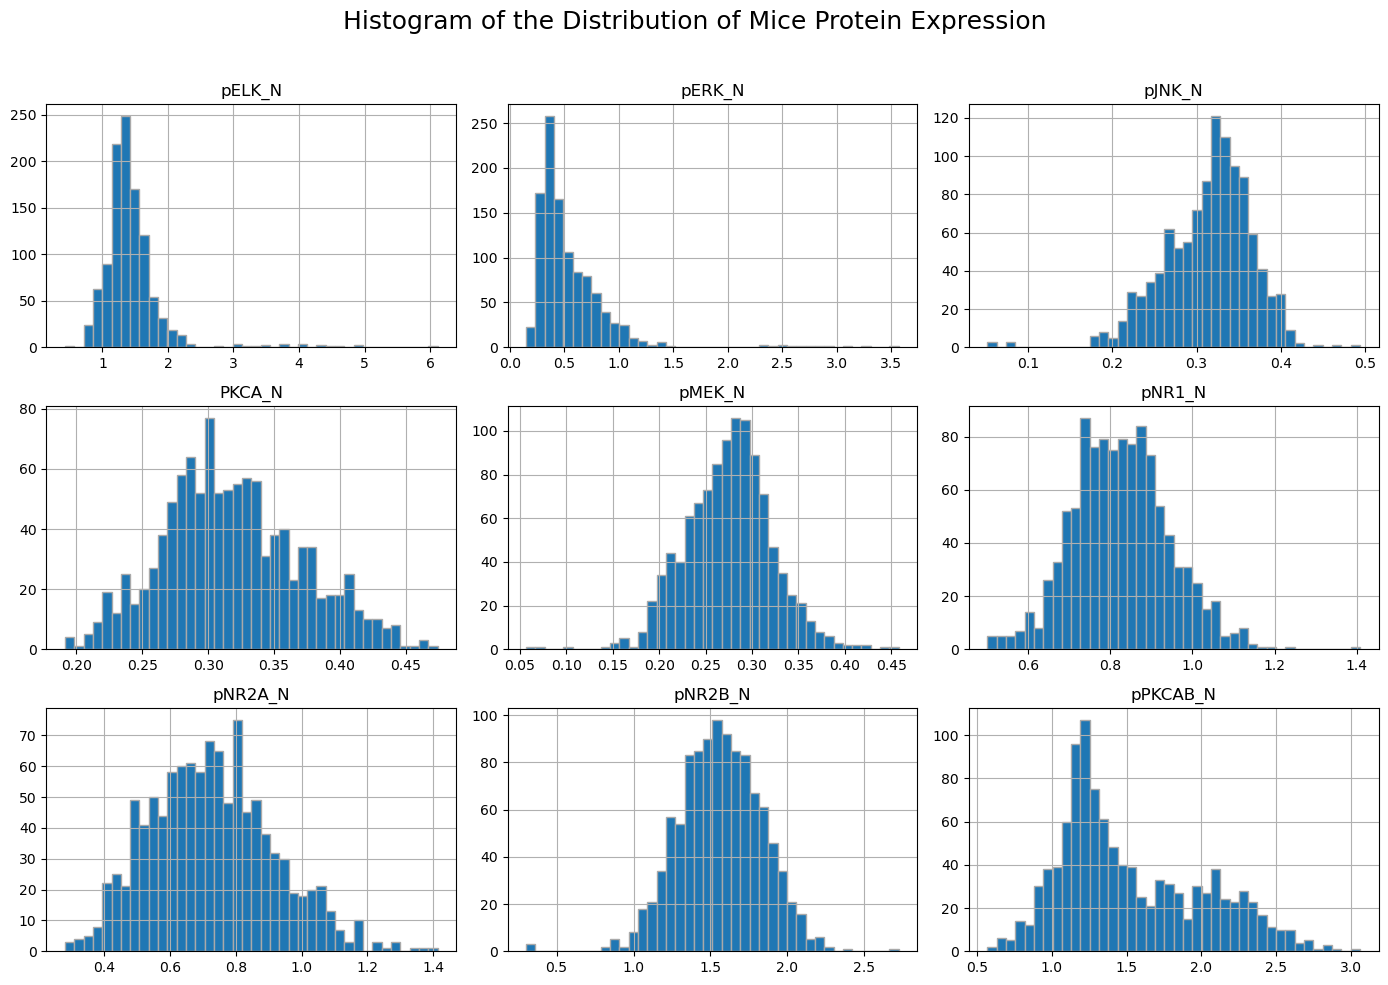

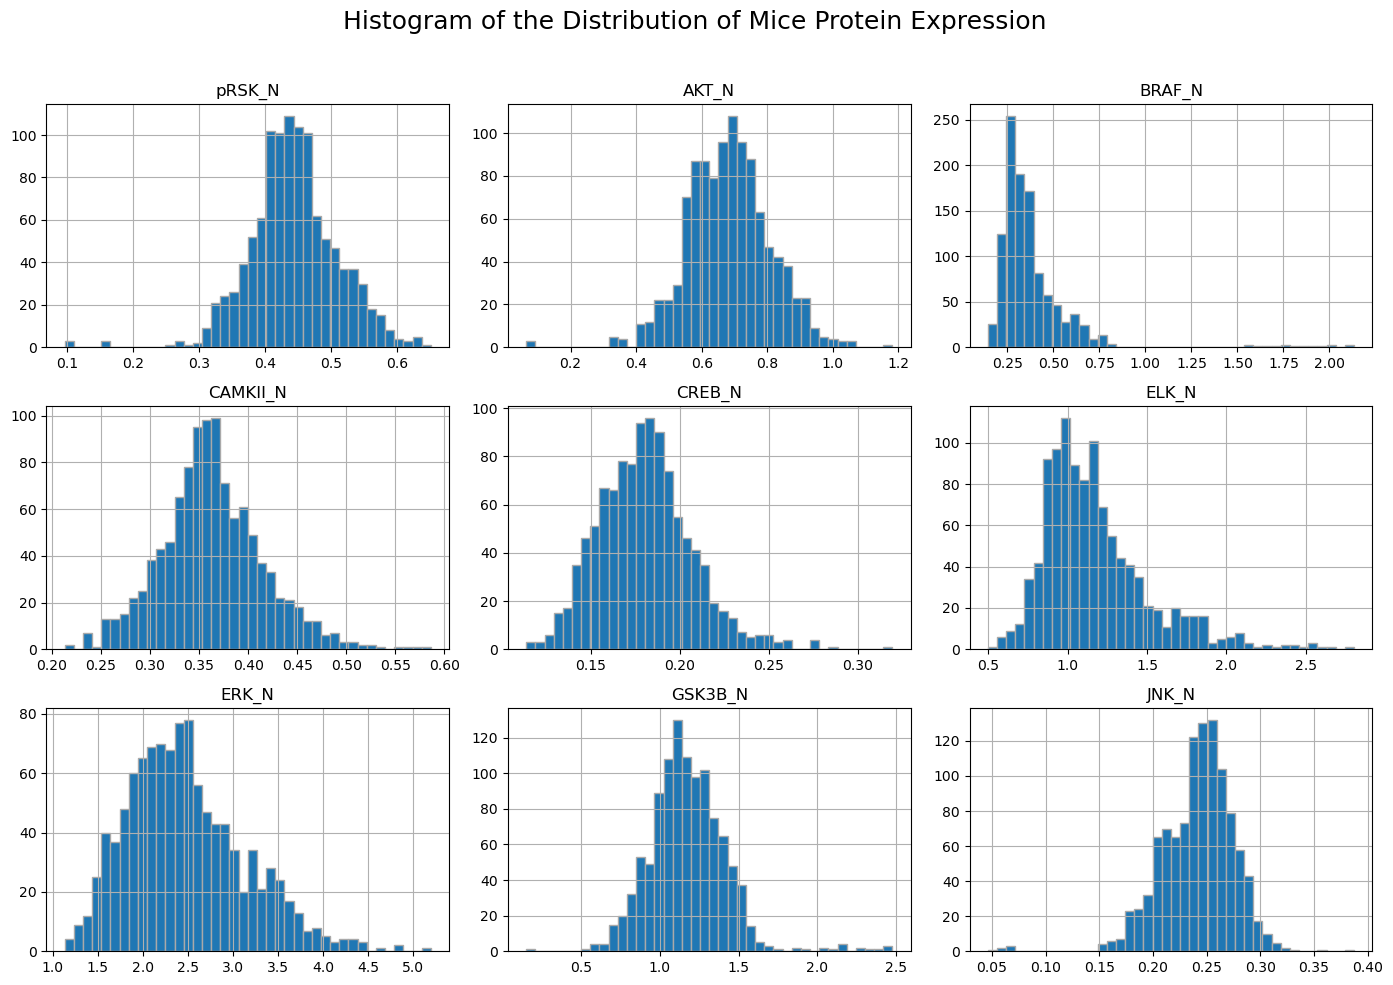

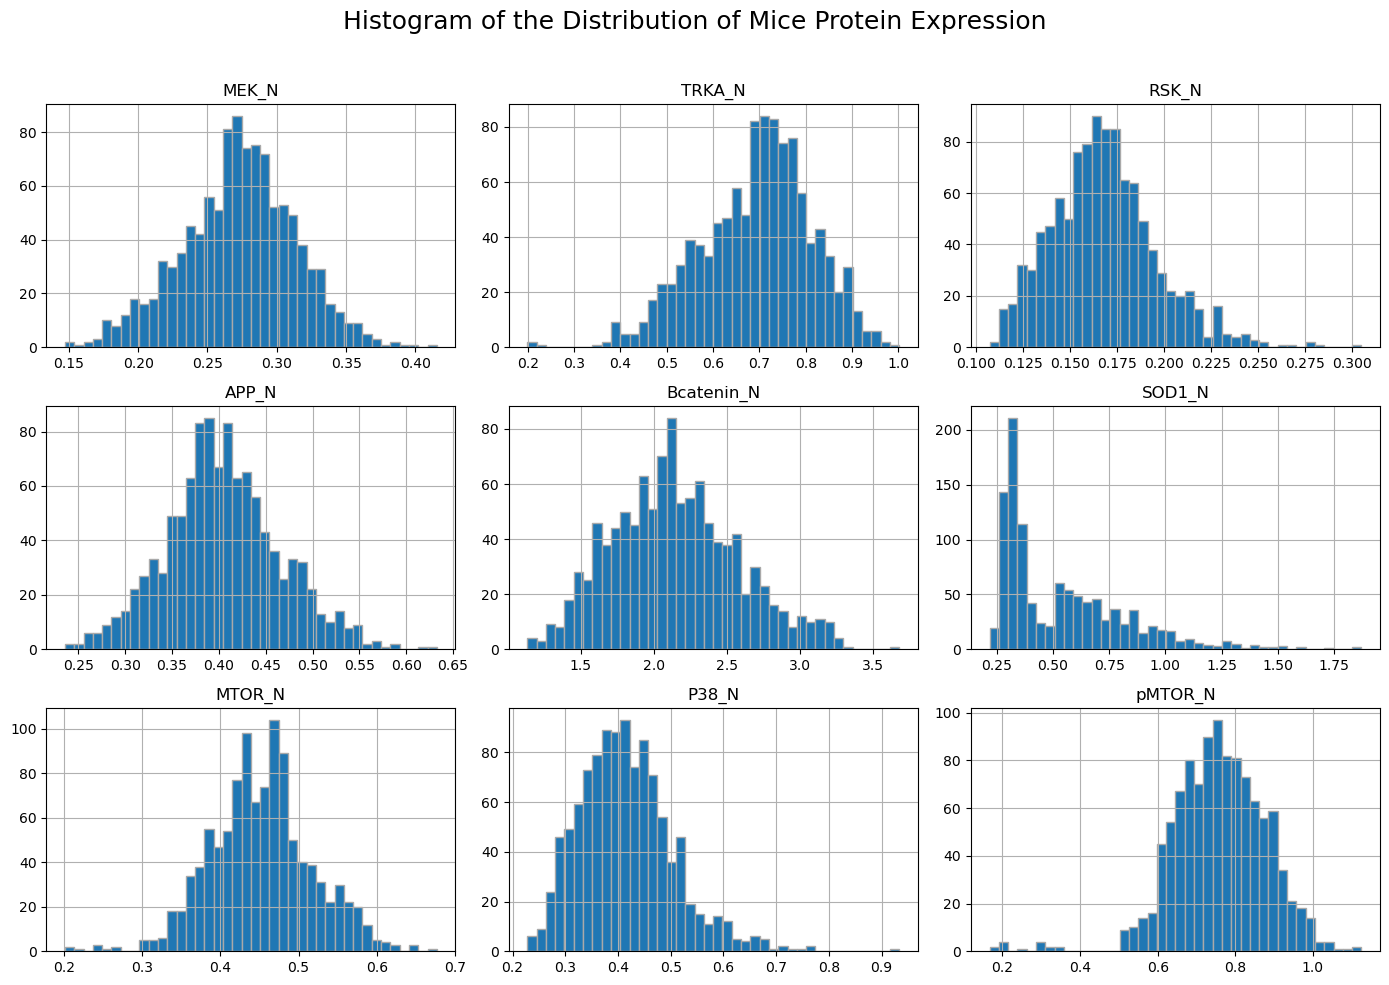

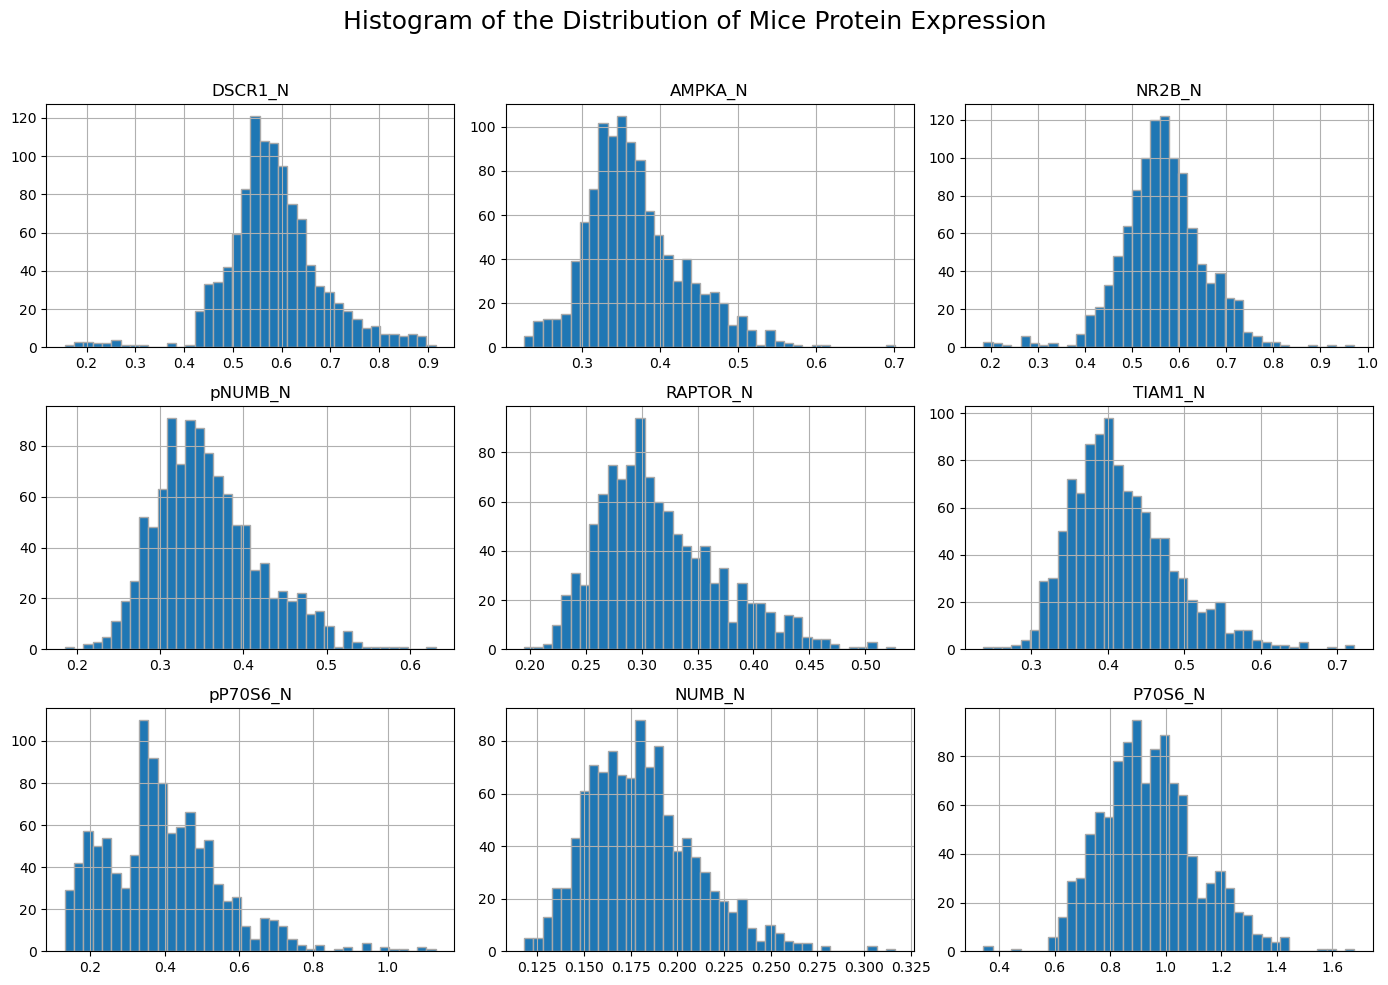

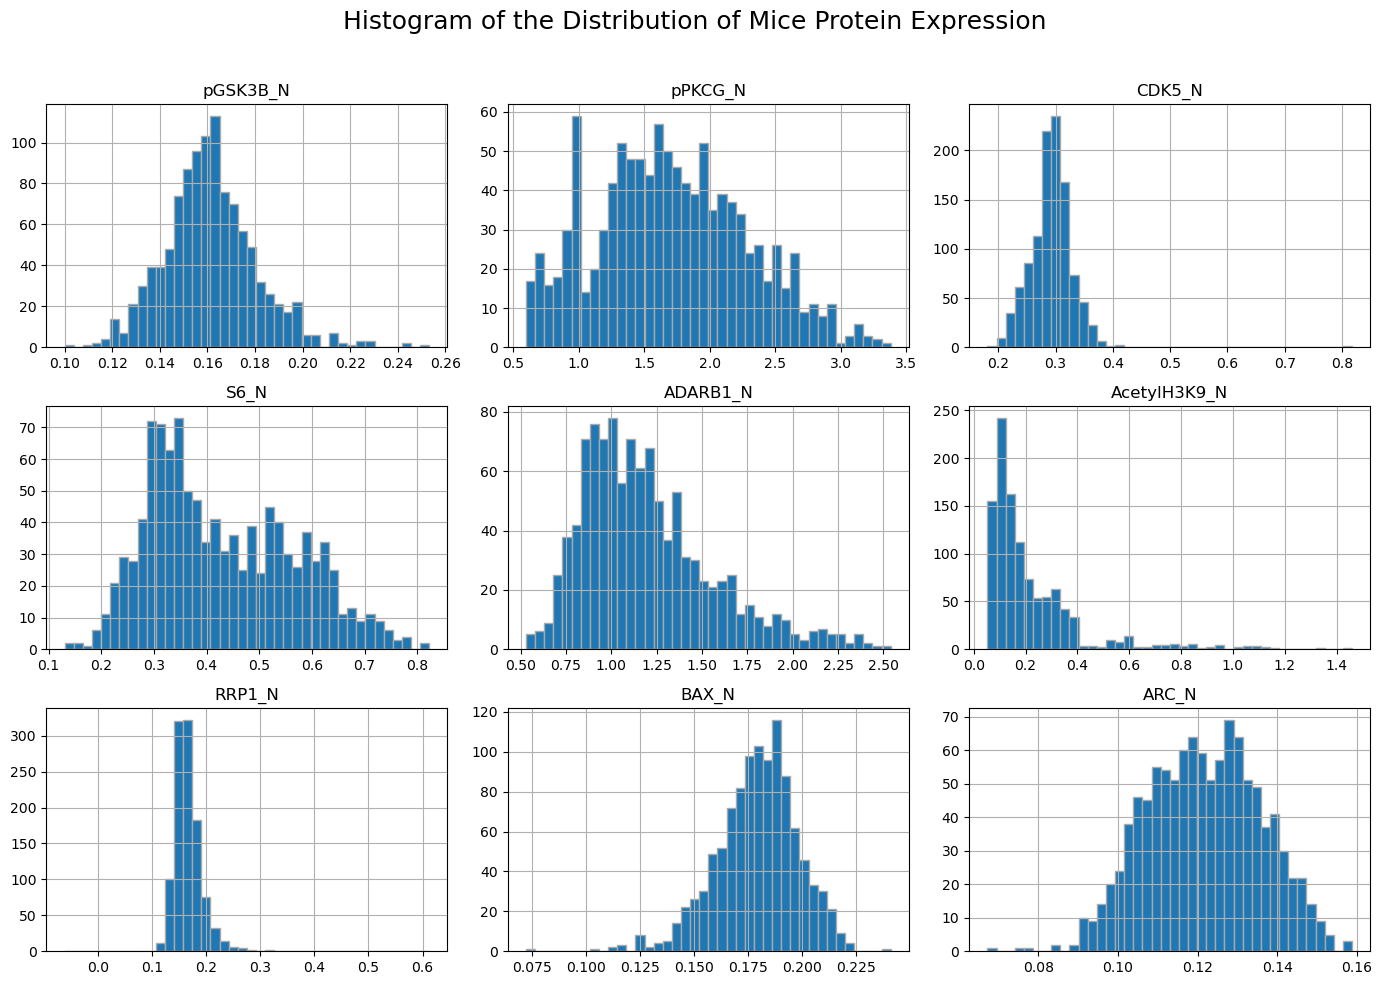

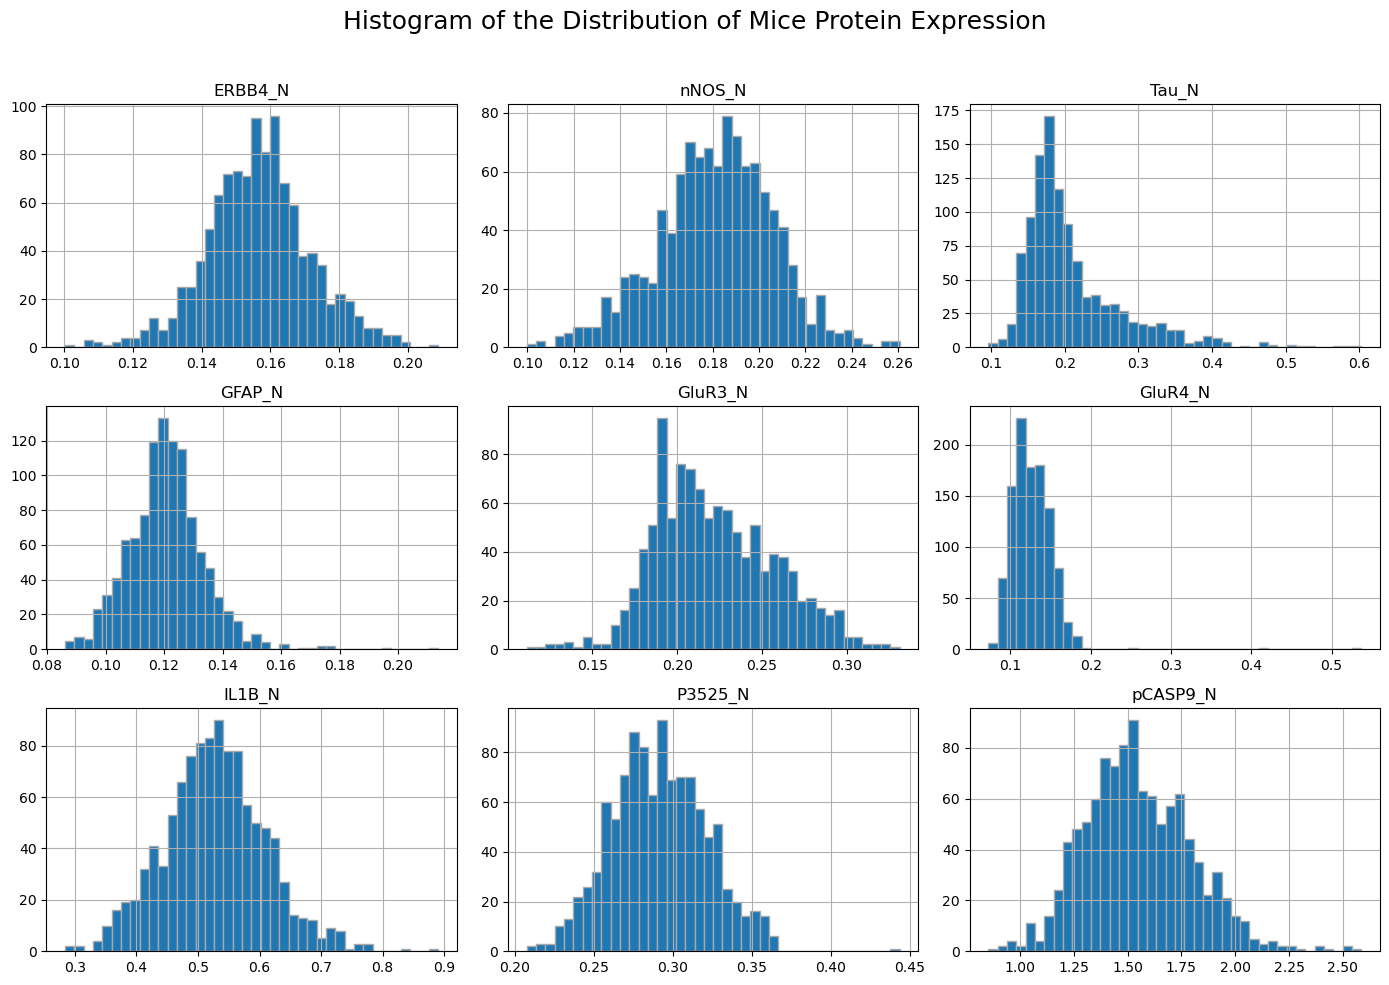

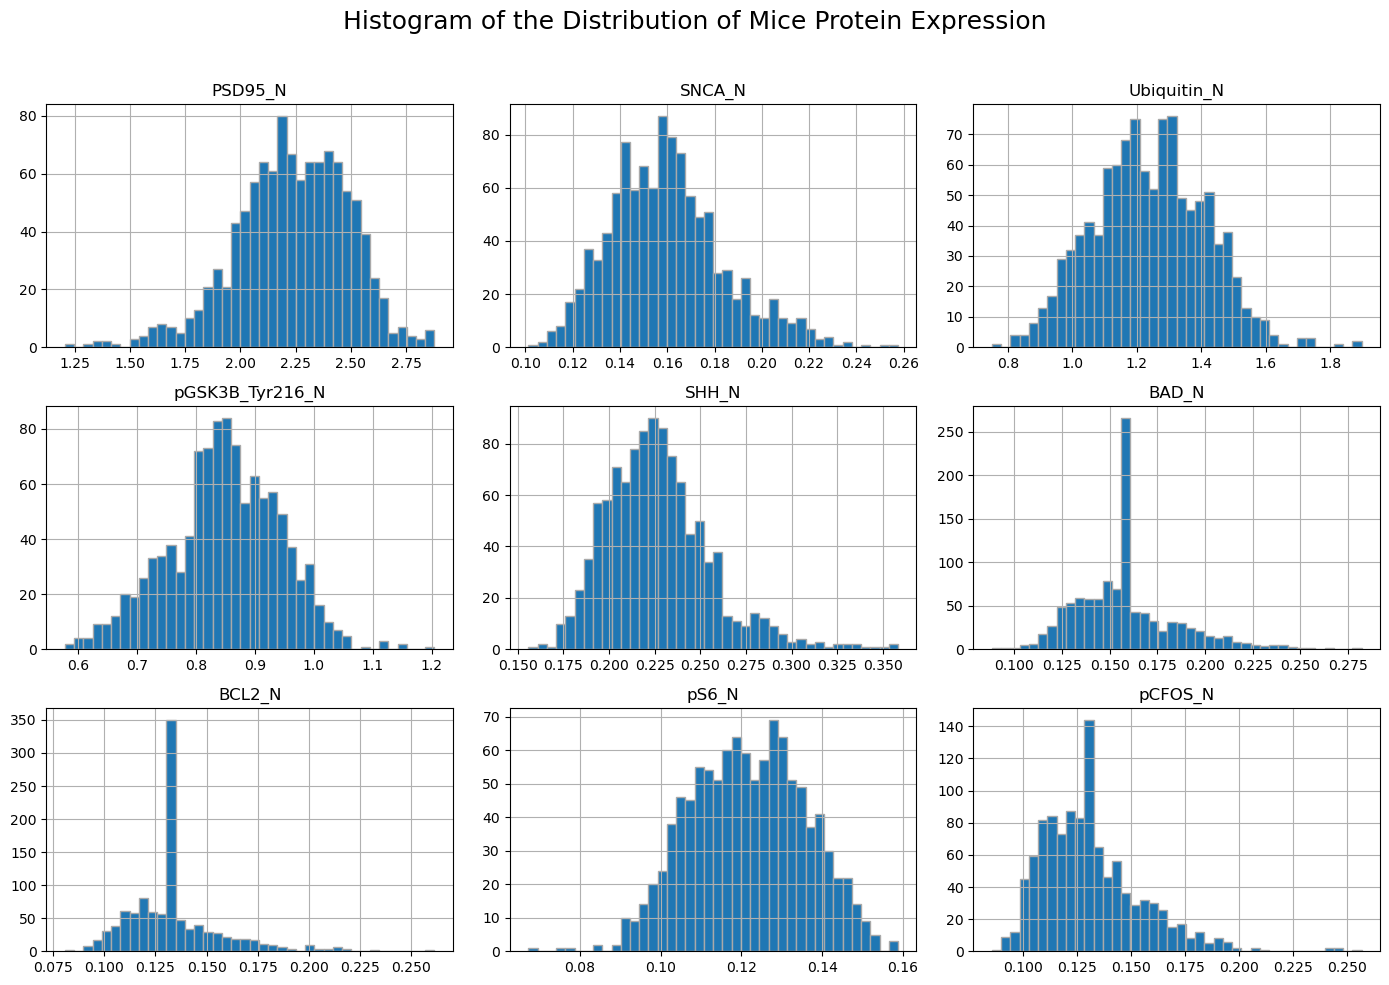

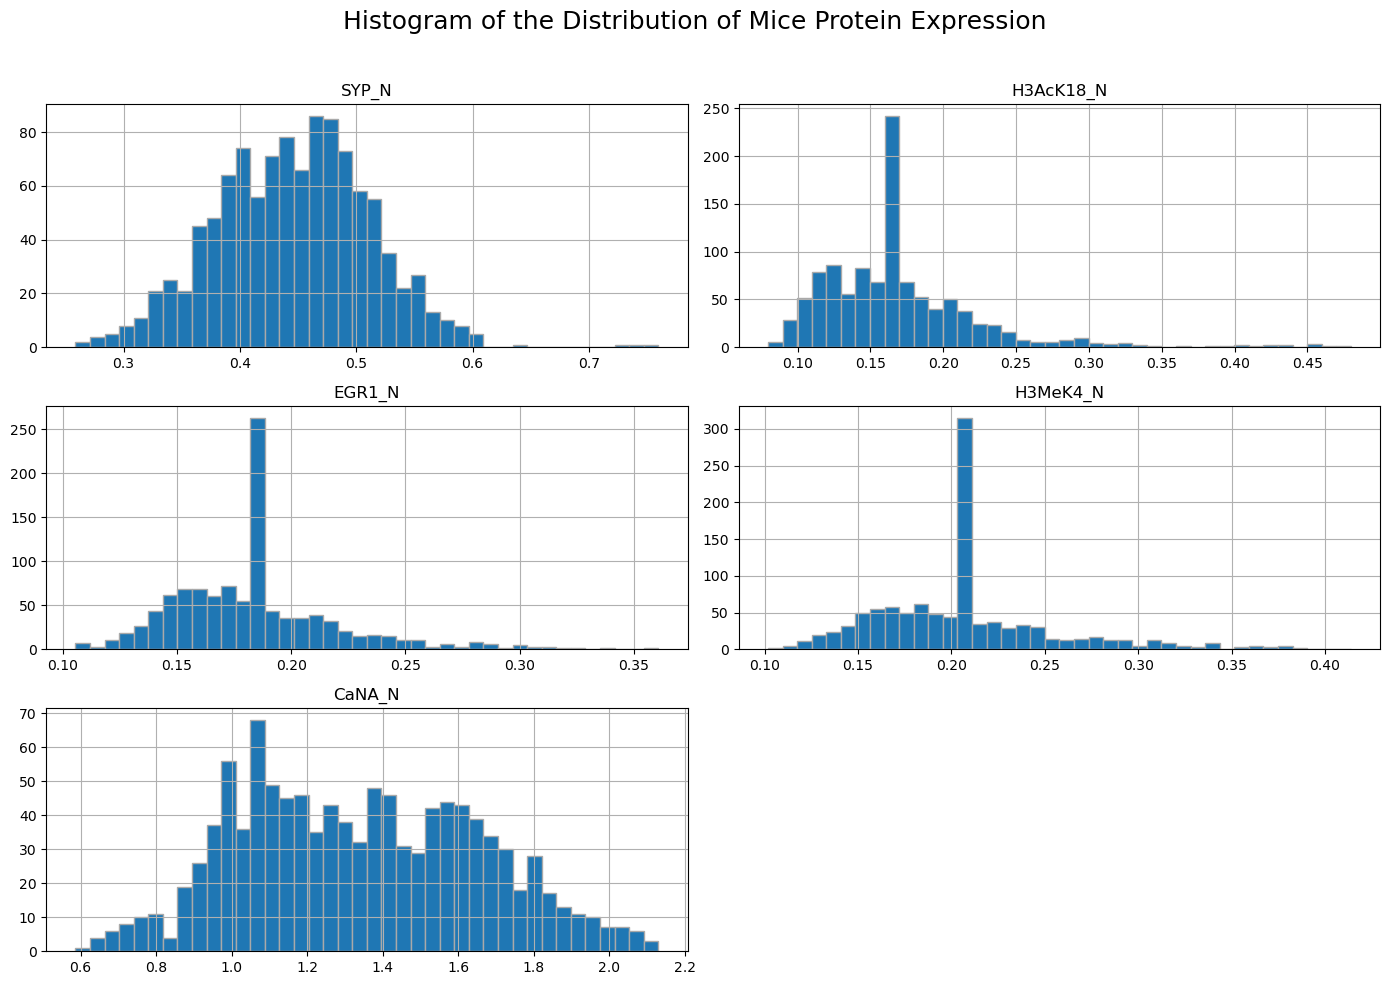

In [53]:
import matplotlib.pyplot as plt

features = df_mpe_numeric.columns

for i in range(0, len(features), 9):
    
    df_mpe_numeric[features[i:i+9]].hist(figsize=(14,10), bins=40, edgecolor = "darkgrey")
    
    plt.suptitle("Histogram of the Distribution of Mice Protein Expression", fontsize = 18)
    
    plt.tight_layout(rect = [0,0,1,0.96])
    
    plt.show()

The histograms show that most protein expression variables follow approximately normal (bell-shaped) distributions, though several are skewed or contain outliers. This indicates variability in protein levels across samples, with some features showing non-normal behaviour that may require scaling or transformation. Overall, the dataset contains a mix of well-behaved and skewed features.

### 3.2 Correlation Heatmap

#### 3.2.1 Correlation Heatmap Plot

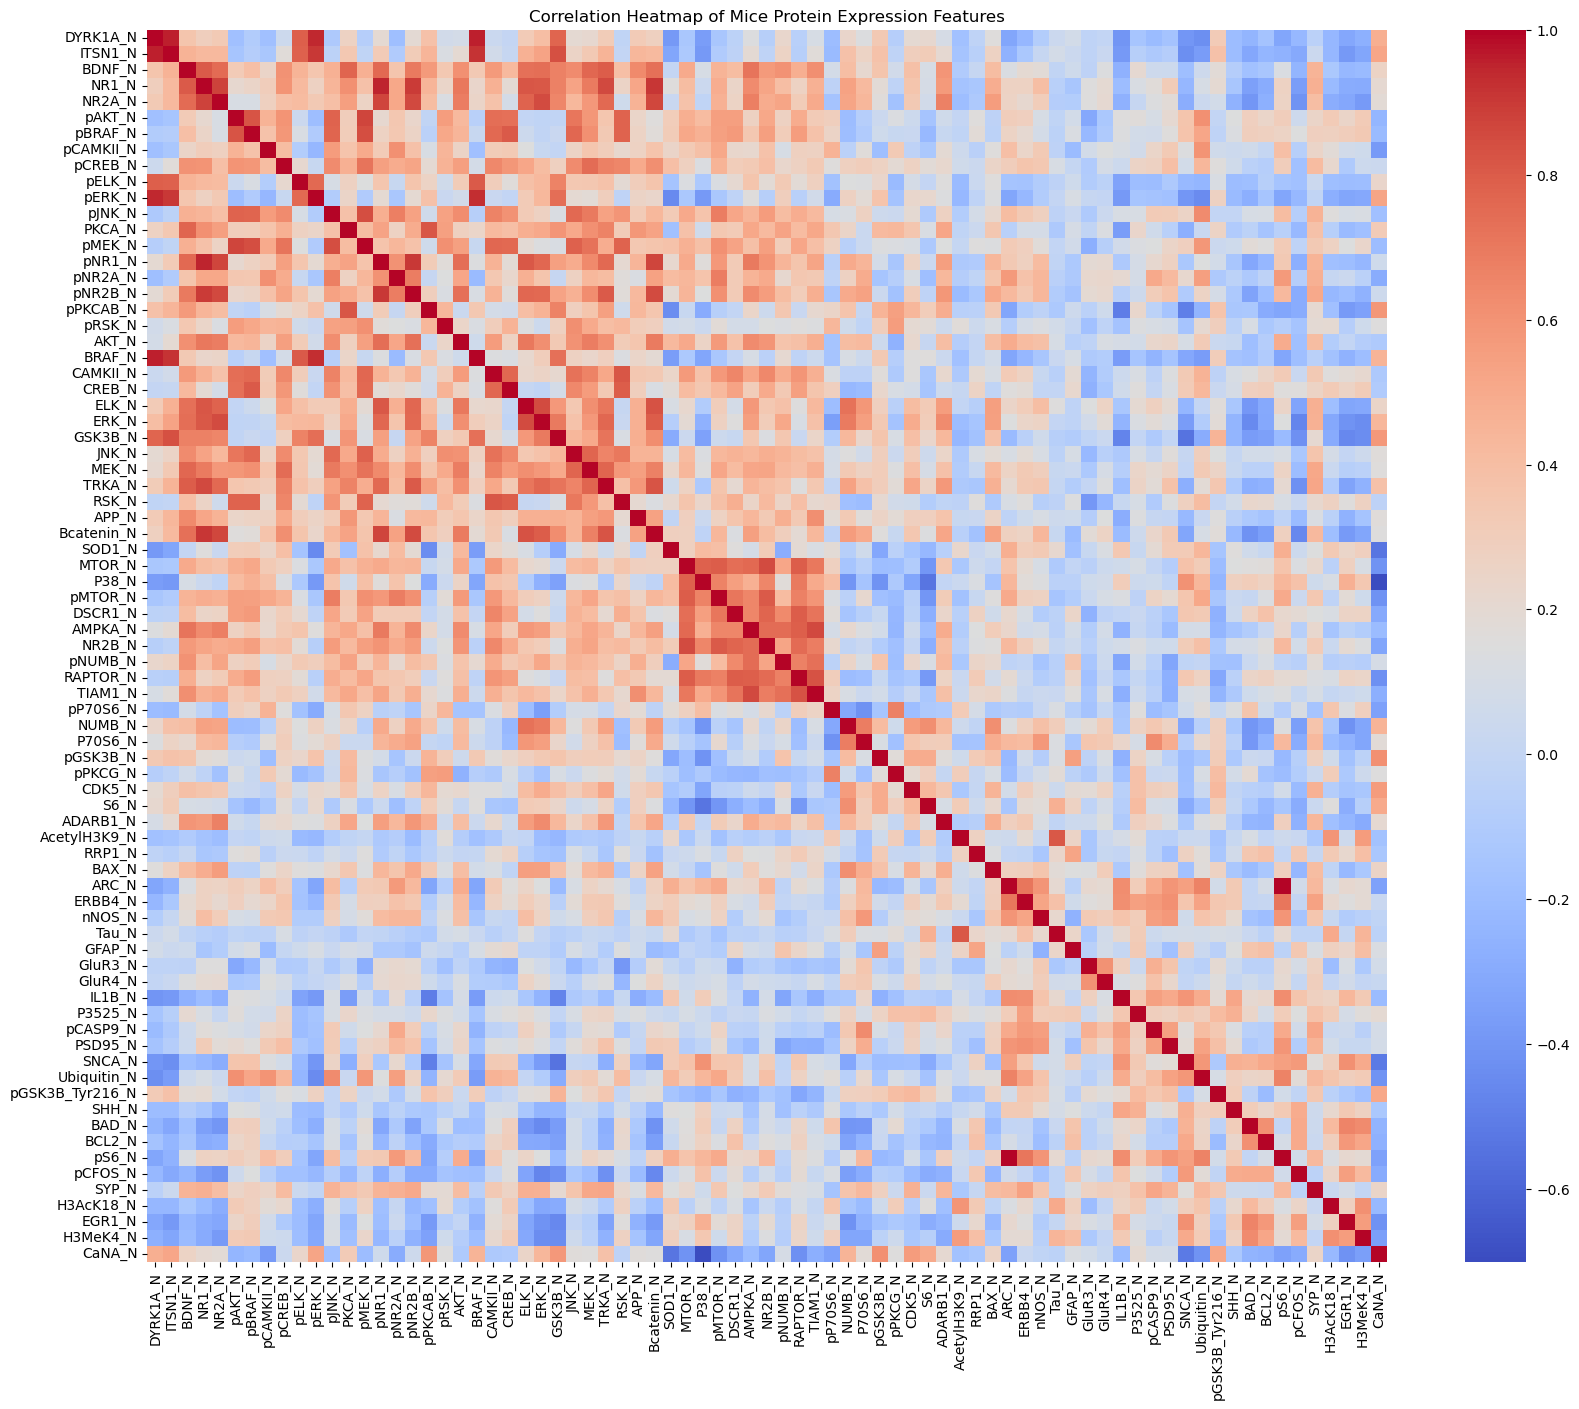

In [28]:
plt.figure(figsize=(20,16))

sns.heatmap(df_mpe_numeric.corr(), cmap="coolwarm")

plt.title("Correlation Heatmap of Mice Protein Expression Features")

plt.show()

The correlation heatmap shows several groups of proteins with strong positive correlations, indicating potential biological relationships and shared pathways. Moderate and negative correlations are also present, suggesting varying degrees of association between features. These clustered patterns support the use of unsupervised learning to identify meaningful groupings in the data.

#### 3.2.2 Correlation Values

In [32]:
corr_matrix_mpe = df_mpe_numeric.corr()

corr_pairs_mpe = corr_matrix_mpe.abs().unstack()

corr_pairs_mpe = corr_pairs_mpe.sort_values(ascending=False)

corr_pairs_mpe = corr_pairs_mpe[corr_pairs_mpe < 1]

corr_pairs_mpe.head(50)

BRAF_N      DYRK1A_N      0.959578
DYRK1A_N    BRAF_N        0.959578
            ITSN1_N       0.959512
ITSN1_N     DYRK1A_N      0.959512
pNR1_N      NR1_N         0.947872
NR1_N       pNR1_N        0.947872
DYRK1A_N    pERK_N        0.945719
pERK_N      DYRK1A_N      0.945719
            BRAF_N        0.926984
BRAF_N      pERK_N        0.926984
ITSN1_N     BRAF_N        0.917608
BRAF_N      ITSN1_N       0.917608
Bcatenin_N  NR1_N         0.913420
NR1_N       Bcatenin_N    0.913420
pNR1_N      pNR2B_N       0.906504
pNR2B_N     pNR1_N        0.906504
ITSN1_N     pERK_N        0.906289
pERK_N      ITSN1_N       0.906289
pNR2B_N     NR1_N         0.895077
NR1_N       pNR2B_N       0.895077
            NR2A_N        0.873889
NR2A_N      NR1_N         0.873889
pAKT_N      pMEK_N        0.873101
pMEK_N      pAKT_N        0.873101
pNR1_N      Bcatenin_N    0.871389
Bcatenin_N  pNR1_N        0.871389
pNR1_N      NR2A_N        0.869717
NR2A_N      pNR1_N        0.869717
Bcatenin_N  NR2A_N  

## 4. Model Training and Evaluation

In [61]:
# Importing relevant libraries to standardise the feature variables before clustering

from sklearn.preprocessing import StandardScaler

scaler_mpe = StandardScaler()

X_scaled_mpe = scaler_mpe.fit_transform(df_mpe_numeric)

### 4.1 Elbow Method

The elbow method is used to identify the optimal number of clusters for the K-Means algorithm.

In [65]:
import warnings 
warnings.filterwarnings("ignore")

from sklearn.cluster import KMeans 

inertia = []

for k in range(1,11) : 

    kmeans_mpe = KMeans(n_clusters = k, random_state = 42)
    kmeans_mpe.fit(X_scaled_mpe)
    inertia.append(kmeans_mpe.inertia_)

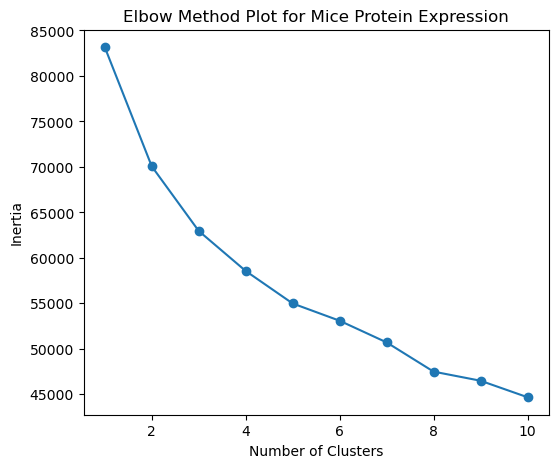

In [66]:
plt.figure(figsize = (6,5))

plt.plot(range(1,11), inertia, marker = "o")

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method Plot for Mice Protein Expression")

plt.show()

The elbow plot shows a sharp decrease in inertia up to around 3–4 clusters, after which the rate of improvement slows down. This indicates that the optimal number of clusters is likely around 3 or 4, where adding more clusters provides diminishing returns.

### 4.2 Training K-Means

In [68]:
kmeans_mpe = KMeans(n_clusters = 3, random_state = 42)

clusters_mpe = kmeans_mpe.fit_predict(X_scaled_mpe)

In [72]:
df_mpe_numeric["Cluster"] = clusters_mpe

### 4.3 Hierachial Clustering

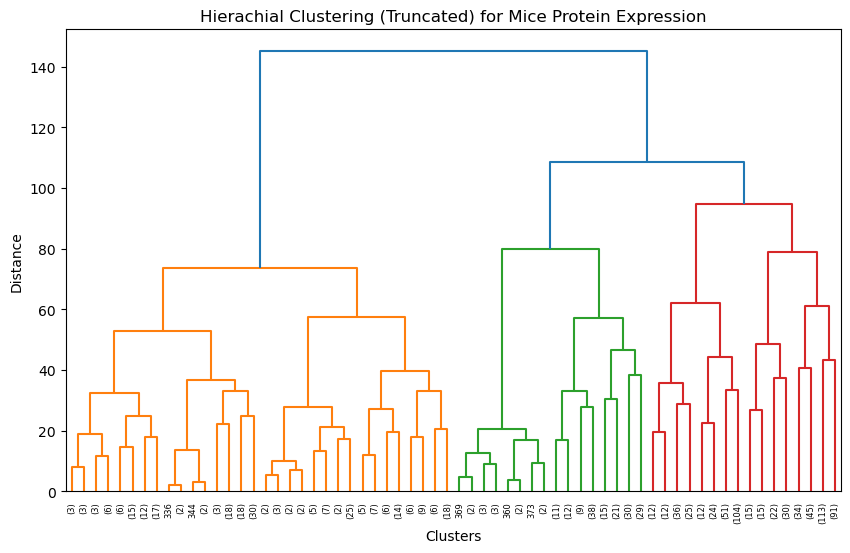

In [106]:
from scipy.cluster.hierarchy import dendrogram, linkage 

plt.figure(figsize = (10,6))

linked_mpe = linkage(X_scaled_mpe, method = "ward")

dendrogram(linked_mpe, truncate_mode = 'level', p = 5)

plt.title("Hierachial Clustering (Truncated) for Mice Protein Expression")

plt.xlabel("Clusters")

plt.ylabel("Distance")

plt.show()

The dendrogram shows clear separation into three main clusters, with larger vertical distances indicating stronger dissimilarity between groups.

### 4.4 Principal Component Analysis (PCA) Cluster Visualisation

In [77]:
from sklearn.decomposition import PCA

pca_mpe = PCA(n_components = 2)

X_pca_mpe = pca_mpe.fit_transform(X_scaled_mpe)

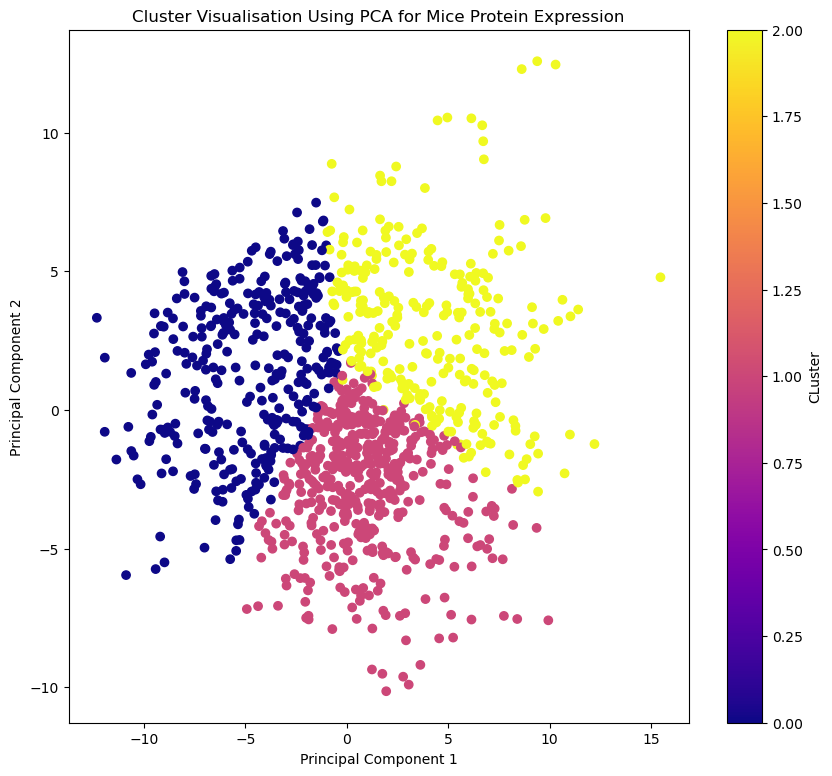

In [79]:
plt.figure(figsize = (10,9))

plt.scatter(X_pca_mpe[:, 0], X_pca_mpe[:,1], c = clusters_mpe, cmap = "plasma")

plt.colorbar(label = "CLuster")

plt.xlabel("Principal Component 1")

plt.ylabel("Principal Component 2")

plt.title("Cluster Visualisation Using PCA for Mice Protein Expression")

plt.show()

Principal Component Analysis (PCA) was applied to reduce the high-dimensional protein expression data into two principal components for visualisation. The scatter plot shows the observations coloured according to their K-Means cluster assignments. The clusters appear relatively well separated, indicating that the algorithm successfully grouped observations with similar protein expression patterns.

### 4.5 Silhouette Score (Cluster Quality)

In [83]:
from sklearn.metrics import silhouette_score

score_mpe = silhouette_score(X_scaled_mpe, clusters_mpe)

print("Silhouette Score:", score_mpe)

Silhouette Score: 0.13180996649427967


#### 4.5.1 Comparing Silhouette Scores for Different K 

In [86]:
silhouette_scores = []

for k in range(2,10): 

    kmeans_mpe = KMeans(n_clusters = k, random_state = 42)
    labels = kmeans_mpe.fit_predict(X_scaled_mpe)
    score_mpe = silhouette_score(X_scaled_mpe, labels)
    silhouette_scores.append(score_mpe)

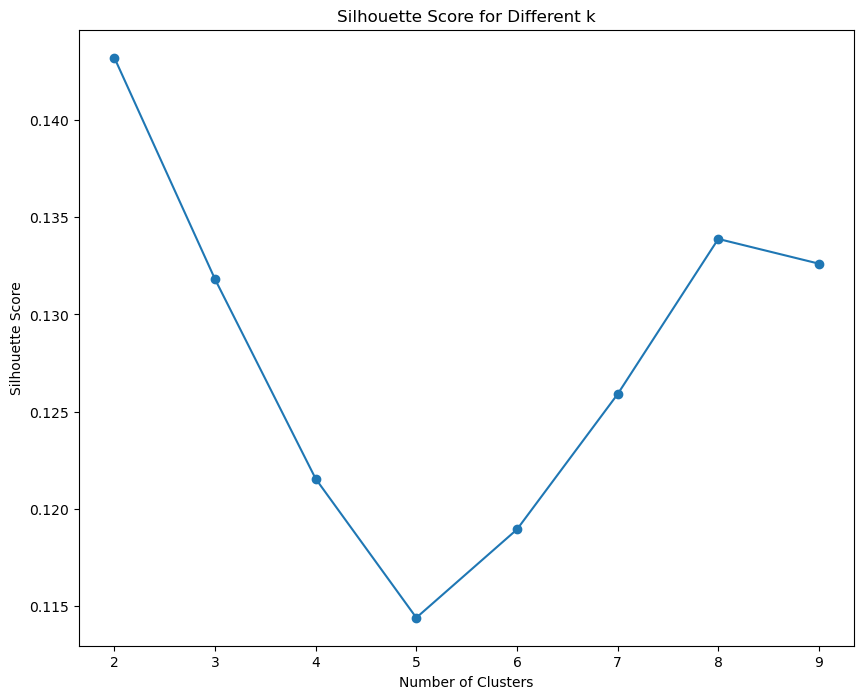

In [87]:
plt.figure(figsize = (10,8))

plt.plot(range(2,10), silhouette_scores, marker = "o")

plt.xlabel("Number of Clusters")

plt.ylabel("Silhouette Score")

plt.title("Silhouette Score for Different k")

plt.show()

The relatively low silhouette scores suggest overlapping clusters, which is expected given the biological complexity and gradual variation in protein expression.

The PCA plot confirms that although clusters are distinguishable, there is some overlap, supporting the moderate silhouette scores.

### 4.6 Cluster Analysis Size

In [89]:
pd.Series(clusters_mpe).value_counts()

1    465
0    336
2    279
Name: count, dtype: int64

The clusters are moderately imbalanced, with Cluster 1 containing the most samples, followed by Cluster 0 and Cluster 2.

### 4.7 Cluster Feature Means 

In [91]:
cluster_means_mpe = df_mpe_numeric.groupby("Cluster").mean()

cluster_means_mpe

,DYRK1A_N,ITSN1_N,BDNF_N,NR1_N,NR2A_N,pAKT_N,pBRAF_N,pCAMKII_N,pCREB_N,pELK_N,...,SHH_N,BAD_N,BCL2_N,pS6_N,pCFOS_N,SYP_N,H3AcK18_N,EGR1_N,H3MeK4_N,CaNA_N
Cluster,,,,,,,,,,,,,,,,,,,,,
0,0.417000,0.580839,0.278275,2.006212,3.167969,0.199358,0.159599,2.617914,0.184666,1.273720,...,0.227986,0.156222,0.132764,0.112409,0.133907,0.399549,0.160014,0.180340,0.200965,1.395371
1,0.326802,0.513134,0.317861,2.301501,3.751256,0.258989,0.198565,4.127505,0.222222,1.373884,...,0.230538,0.167328,0.143772,0.127770,0.137049,0.456131,0.188504,0.198502,0.225766,1.146561
2,0.601434,0.834052,0.370286,2.640736,4.812462,0.230851,0.180775,3.660104,0.230103,1.706632,...,0.218663,0.144263,0.122151,0.122078,0.117623,0.485338,0.149673,0.160887,0.176951,1.587136


#### 4.7.1 Cluster Feature Means Plot

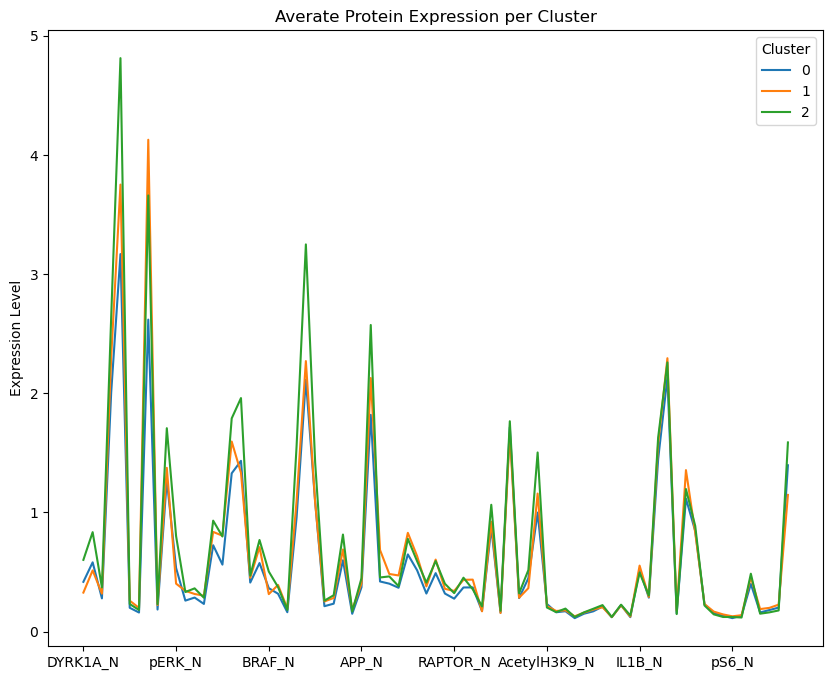

In [93]:
cluster_means_mpe.T.plot(figsize = (10,8))

plt.title("Averate Protein Expression per Cluster")

plt.ylabel("Expression Level")

plt.show()

The clusters exhibit distinct expression patterns across proteins, indicating meaningful differences in protein activity between groups.

### 4.8 Cluster Heatmap of Feature Means

In [95]:
cluster_means_scaled_mpe = pd.DataFrame(scaler_mpe.fit_transform(cluster_means_mpe),
                                        index = cluster_means_mpe.index, 
                                        columns = cluster_means_mpe.columns)

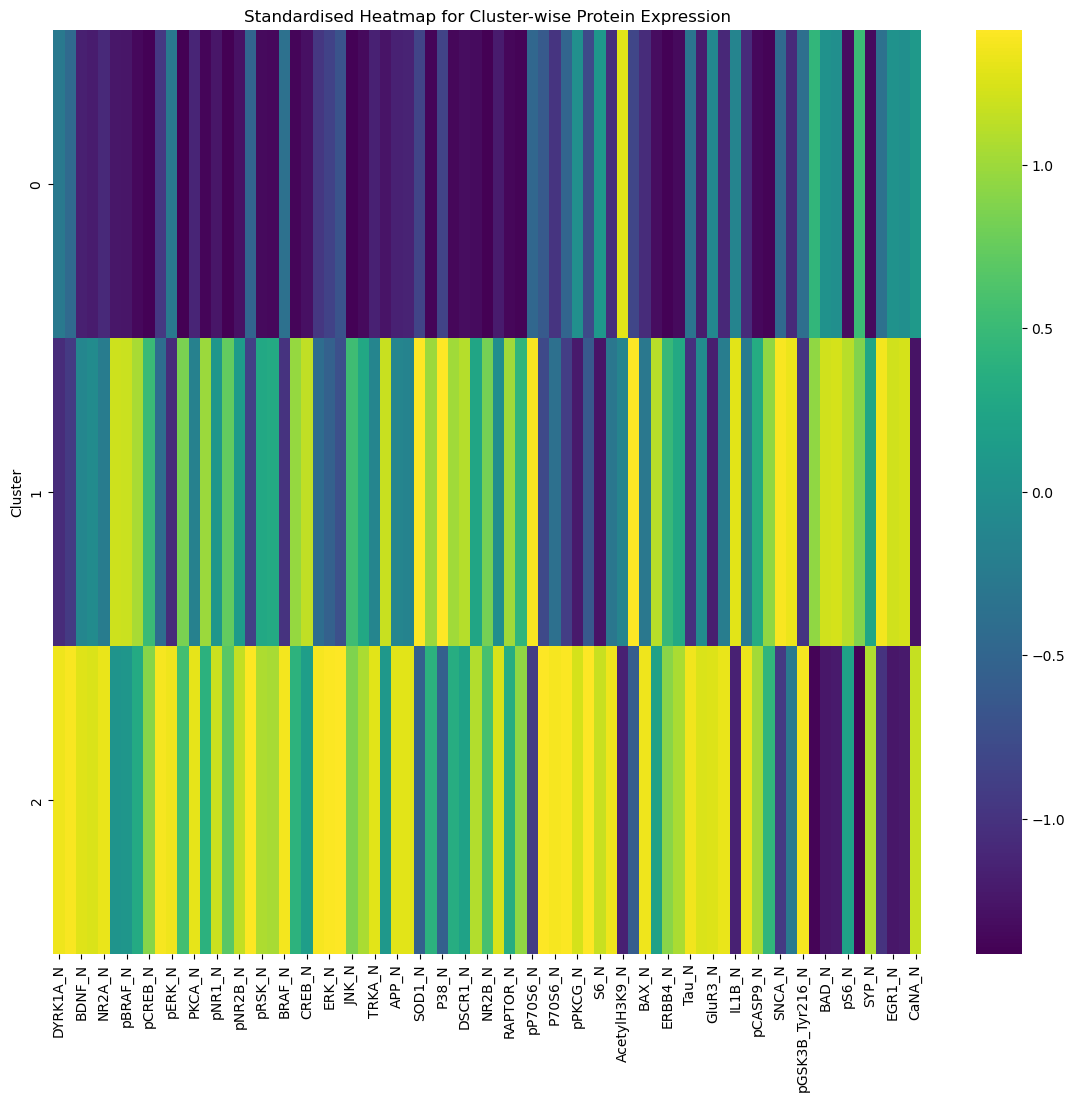

In [109]:
plt.figure(figsize = (14,12))

sns.heatmap(cluster_means_scaled_mpe, cmap = "viridis", center = 0)

plt.title("Standardised Heatmap for Cluster-wise Protein Expression")

plt.show()

The heatmap shows the average protein expression levels for each cluster. 
To improve interpretability, the values were standardised so that differences 
between clusters can be compared more clearly. The plot highlights variations in protein expression patterns, indicating that 
each cluster exhibits distinct biological characteristics.

### 5. Conclusion 

Overall, the clustering analysis reveals the presence of three distinct groups within the dataset, supported by the elbow method, dendrogram, and PCA visualisation. However, the relatively low silhouette scores and some overlap between clusters indicate that the separation is moderate rather than strong. This suggests that while meaningful patterns exist in protein expression, the differences between groups are not highly pronounced. These clusters likely reflect underlying biological variation in protein expression, potentially associated with differences in genotype or treatment conditions within the dataset.